# Optimization
The topic of this notebook is optimization, that is minimizing or maximizing an objective function often under constraints represented as equations or inequalities, e.g. in two variables
$$\begin{align*}
& \min_{x,y} f(x,y) \\ 
& \textrm{s.t.}  \ x \gt 0, \ y \gt 0 
\end{align*}$$
If the objective function and the constraints are linear thee problem is classified as **linear programming**. Generally optimization problems are very difficult to solve. One problem is that an algorithm may stop at a local minimum and fail to find the global one. A particular class of optimization problems are those called **convex problems**. A function that is convex in an interval $[a,b]$ has only one global minimum and no local ones. Minimizing an objective function $f(x,y)$ means finding the roots of its derivative, or of the components of its gradient
$$\nabla f(x,y) = 0 $$
The root points $(x^*,y^*)$ can be a minimum, maximum or saddle point. In order to distinguish the type of point we need the 2nd derivative, or the hessian
$$H(x,y)=\frac{\partial^{2} f(x,y)}{\partial x_{i} \partial x_{j}}$$
If $H(x^*,y^*) \gt 0$ then $(x^*,y^*)$ is a minimum, if $H(x^*,y^*) \lt 0$ $(x^*,y^*)$ is a maximum and if $H(x^*,y^*) = 0$ then $(x^*,y^*)$ is a saddle point.  
The examples in this notebook follow those from chapter 6 of the book by Johansson [*Numerical Python, 3rd Edition*](https://github.com/jrjohansson/numerical-python-book-code/blob/master/ch06-code-listing.ipynb). 

In [1]:
import numpy as np
import sympy
import scipy
from scipy import linalg as la
from scipy import optimize
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
print('NumPy version: {}'.format(np.__version__))
print('SymPy version: {}'.format(sympy.__version__))
print('SciPy version: {}'.format(scipy.__version__))
print('Matplotlib version: {}'.format(mpl.__version__))

NumPy version: 1.26.4
SymPy version: 1.14.0
SciPy version: 1.17.1
Matplotlib version: 3.8.4


## Univariate optimization
In order to find the minimum of an univariate objective function we can use the same techniques, such as the [Newton method](https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization), that we saw to find the roots of an equation of the type $f'(x) = 0$ with f' being the first derivative of $f(x)$. The Newton method for optimization involves the computation of the second derivative $f''(x)$. The [SciPy optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html#optimization) module provides methods for the optimization of a scalar univariate function. As an example we find the minimum area of a cylinder with constant (unit) volume. The area of a cylinder depends on two variables: its radius and height. We write the minimization problems as
$$\begin{align*}
& \min_{r,h} A = 2 \pi r^2 + 2 \pi r h \\ 
& \textrm{s.t.} \ \pi r^2 h = 1 
\end{align*}$$
From the expression of the constraint we have  
$$h = \frac{1}{\pi r^2}$$ 
Substituting into the objective function we have the function to be minimized 
$$A = 2 \pi r^2 + \frac{2}{r}$$

In [110]:
def f(r):
    return 2 * np.pi * r**2 + 2 / r

In [111]:
opt = optimize.minimize_scalar(f, bracket=(0.1, 4))
opt

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 5.535810445932086
       x: 0.5419260772557135
     nit: 15
    nfev: 18

In [4]:
r_min = opt['x']
r_min

0.5419260772557135

In [5]:
r = np.linspace(0, 2, 100)[1:]

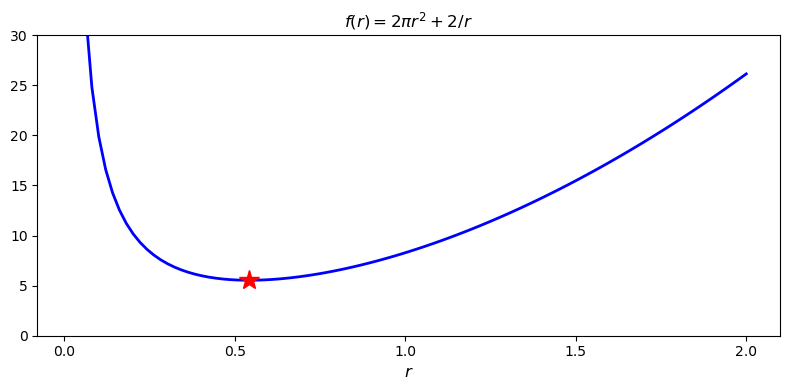

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r, f(r), lw=2, color='b')
ax.plot(r_min, f(r_min), 'r*', markersize=15)
ax.set_title(r"$f(r) = 2\pi r^2+2/r$", fontsize=12)
ax.set_xlabel(r"$r$", fontsize=12)
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_ylim(0, 30)
fig.tight_layout()

### Nonlinear Least-Squares Problems
The general problem addressed by the least-squares method is to minimize an objective function of the form
$$f(x) = \frac{1}{2} \sum_{j=1}^m r_j^2(x)$$
where $r_j$ represent the *residual*, that is the difference between an observation $(x_j,y_j)$ and a parametrized function $\hat{y}(x, \beta)$ that represents our model of an unkown true function $y^*(x)$
$$r_j = y_j - \hat{y}(x_j, \beta)$$
The model $\hat{y}(x, \beta)$ can be represented as polynomials of order n. The number m of observation must be greater than the order n of the polynomials. If the parameters $\beta$ are linear we can solve the optimization problem using linear algebra methods (see [Ch.5 - Equation Solving](equation_solving.ipynb)). In this section we develop an example of univariate nonlineear least-squares problem.

We define an univariate function that is non linear in one of its parameters $\beta$. This function represents the unknown "true" function that we want to approximate
$$\hat{y}(x,\beta) = \beta_0 + \beta_1 e^{-\beta_2 x^2} $$

In [23]:
def f(x, beta0, beta1, beta2):
    return beta0 + beta1 * np.exp(-beta2 * x**2)

We create a set of observations using our model adding some noise to the values returned by the function

In [24]:
beta = (0.25, 0.75, 0.5)
xdata = np.linspace(0, 5, 50)
y = f(xdata, *beta)
ydata = y + 0.05 * np.random.randn(len(xdata))

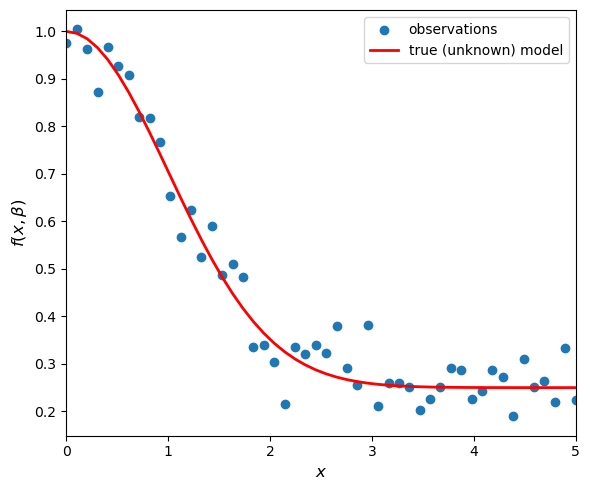

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(xdata, ydata, label="observations")
ax.plot(xdata, y, 'r', lw=2, label="true (unknown) model")
ax.set_xlim(0, 5)
ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel(r"$f(x, \beta)$", fontsize=12)
ax.legend()
fig.tight_layout()

Since the function $\hat{y}(x,\beta)$ is nonlinear in the $\beta$ parameters we cannot use the linear algebra approach to minimize the objective function $f(x, \beta)$. We have to use a numerical method. One such method is the [Levenberg-Marquardt](https://en.wikipedia.org/wiki/Levenberg%E2%80%93Marquardt_algorithm) algorithm (see Nocedal, p.258 for more info) that is similar to the standard Newton-Gaussian method that is an iterative approximation process where the first derivative (Jacobian) of the objectve function is calculated with respect to the $\beta$ parameters
$$J = \frac{\partial f(x, \beta)}{\partial \beta}$$
The Levenberg-Marquardt is implemented in [SciPy's leastsq()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.leastsq.html) method. The method takes as input a set of residuals 

In [30]:
def g(beta):
    return ydata - f(xdata, *beta)

The result of the optiminization are the values of $\beta$ for which the model fits the data 

In [31]:
beta_start = (1, 1, 1)
beta_opt, beta_cov = optimize.leastsq(g, beta_start)
beta_opt

array([0.2602923 , 0.72845313, 0.49688268])

We plot the model function with the optimal parameters together with the "true" function and the observations

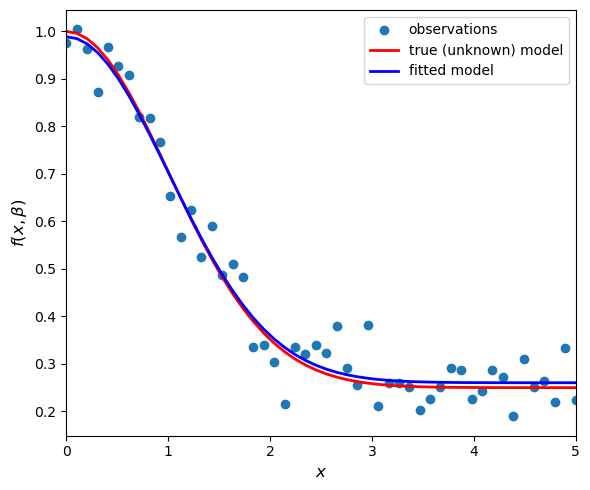

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(xdata, ydata, label="observations")
ax.plot(xdata, y, 'r', lw=2, label="true (unknown) model")
ax.plot(xdata, f(xdata, *beta_opt), 'b', lw=2, label="fitted model")
ax.set_xlim(0, 5)
ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel(r"$f(x, \beta)$", fontsize=12)
ax.legend()
fig.tight_layout()

## Unconstrained Multivariate Optimization
The approach for the optimization of a multivariate function is not conceptually different from that used for univariate ones. In the multivariate case the objective function is a surface in a multidimensional space for which we want to find its global minimum. As in the univariate case, we can search for a global minimum by solving the equation $\nabla f(x_1,x_2,...,x_n)=0$, where $\nabla f$ is the gradient of the objective function. An analytical solution is available only for simple cases so that the numerical approach is usually necessary. A first numerical approach, like in the univariate case is to evaluate the objectve function to look for points where its sign changes. This approach takes usually a long time depending on the dimensionality of the objective function. Again, as for the univariate case, a better approach is to use the derivative, that is the gradient, of the derivative of the objective function, $\nabla^2 (x_1,x_2,...,x_n)$, that is the hessian of the objective function. The [SciPy optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html#local-multivariate-optimization) module provides several numerical methods to find the minimum of an objective function. We work out an example with a simple objective function that depends only on two variables and could be solved by the symbolic method.
$$f(x_1, x_2) = (x_1 - 1)^4 + 5(x_2 - 1)^2 - 2 x_1 x_2$$. 
The first step is to compute the gradient of the objective function from which we have two equations
$$\nabla f(x_1, x_2) = 0$$

We can use SymPy to solve the equation symbolically. We define the two symbols for the independent variables, the objective function and then we use the [SymPy diff()](https://docs.sympy.org/latest/modules/core.html#sympy.core.function.diff) method to compute the derivatives with respect to the two variables.

In [25]:
x1, x2 = sympy.symbols("x_1, x_2")
f_sym = (x1 - 1)**4 + 5 * (x2 - 1)**2 - 2 * x1 * x2
fprime_sym = [f_sym.diff(x_) for x_ in (x1, x2)]
sympy.Matrix(fprime_sym)

Matrix([
[-2*x_2 + 4*(x_1 - 1)**3],
[   -2*x_1 + 10*x_2 - 10]])

We also need the [hessian](https://en.wikipedia.org/wiki/Hessian_matrix) to determine the type of roots of the gradient: local minimum, local maximum or saddle point
$$H(x_i, x_j)=\frac{\partial^2 f(x_1, x_2)}{\partial x_i x_j}$$

In [32]:
fhess_sym = [[f_sym.diff(x1_, x2_) for x1_ in (x1, x2)] for x2_ in (x1, x2)]
sympy.Matrix(fhess_sym)

Matrix([
[12*(x_1 - 1)**2, -2],
[             -2, 10]])

### Symbolic solution
We can use SymPy to solve the simple nonlinear system of the two first derivatives of the objective function

In [82]:
symbolic_solutions = sympy.nonlinsolve(fprime_sym, [x1, x2])
symbolic_solutions

{((-2*30**(1/3) + (sqrt(72870) + 270)**(2/3) + 30**(2/3)*(sqrt(72870) + 270)**(1/3) - 3*10**(2/3)*3**(1/6)*I*(sqrt(72870) + 270)**(1/3) + sqrt(3)*I*(sqrt(72870) + 270)**(2/3))/((30**(2/3) - 3*10**(2/3)*3**(1/6)*I)*(sqrt(72870) + 270)**(1/3)), 6/5 + 1/(750*(-1/2 + sqrt(3)*I/2)*(sqrt(72870)/112500 + 3/1250)**(1/3)) + (-1/2 + sqrt(3)*I/2)*(sqrt(72870)/112500 + 3/1250)**(1/3)), ((-2*30**(1/3) + (sqrt(72870) + 270)**(2/3) + 30**(2/3)*(sqrt(72870) + 270)**(1/3) - sqrt(3)*I*(sqrt(72870) + 270)**(2/3) + 3*10**(2/3)*3**(1/6)*I*(sqrt(72870) + 270)**(1/3))/((30**(2/3) + 3*10**(2/3)*3**(1/6)*I)*(sqrt(72870) + 270)**(1/3)), 6/5 + (-1/2 - sqrt(3)*I/2)*(sqrt(72870)/112500 + 3/1250)**(1/3) + 1/(750*(-1/2 - sqrt(3)*I/2)*(sqrt(72870)/112500 + 3/1250)**(1/3))), (30**(2/3)/(30*(sqrt(72870) + 270)**(1/3)) + 30**(1/3)*(sqrt(72870) + 270)**(1/3)/30 + 1, 1/(750*(sqrt(72870)/112500 + 3/1250)**(1/3)) + (sqrt(72870)/112500 + 3/1250)**(1/3) + 6/5)}

We can see that only one solution is real. We will compare the real symbolic solution with the numerical one

In [97]:
for sol in symbolic_solutions:
    x = sympy.N(sol[0])
    y = sympy.N(sol[1])
    print('x = {}, y = {}\n'.format(x, y))

x = 1.88292612929632, y = 1.37658522585926

x = 0.558536935351839 + 0.696181666194707*I, y = 1.11170738707037 + 0.139236333238941*I

x = 0.558536935351839 - 0.696181666194707*I, y = 1.11170738707037 - 0.139236333238941*I



It can be useful to plot the objective function in a 3D space, while looking for its minimum or maximum point. For the plot we need a regular grid (meshgrid), with the X1 and X2 matrices, and the values of the function for each point in the grid. We can get the matrix with the numerical values of the objective function from its symbolic expression or by computing the numerical values from the grid point (X1,X2). In the first case we have to use the [SymPy lambify()](https://docs.sympy.org/latest/tutorials/intro-tutorial/basic_operations.html#lambdify) function to evaluate the symbolic expression.  

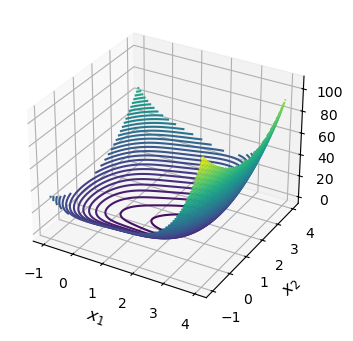

In [20]:
fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': '3d'})
x1 = x2 = np.linspace(-1, 4, 100)
X1, X2 = np.meshgrid(x1, x2)
#f_lambda = sympy.lambdify((x1, x2), f_sym, 'numpy')
f_num = (X1 - 1)**4 + 5 * (X2 - 1)**2 - 2 * X1 * X2
#c = ax.contour(X1, X2, f_lambda(X1, X2), 50)
c = ax.contour(X1, X2, f_num, 50)
ax.set_xlabel(r"$x_1$", fontsize=12)
ax.set_ylabel(r"$x_2$", fontsize=12);

### Numerical solution
Since an analytical solution is not always available we will calculate the solutions of our optimization problem by a numerical method. In order to use the symbolic expression for numerical computation we have to transform them using SymPy's lambdify()

In [124]:
f_lambda = sympy.lambdify((x1, x2), f_sym, 'numpy')

In [125]:
f_lambda(1.88292612929632, 1.37658522585926)

-3.8672228877127957

In [126]:
fprime_lambda = sympy.lambdify((x1, x2), fprime_sym, 'numpy')

In [127]:
fhess_lambda = sympy.lambdify((x1, x2), fhess_sym, 'numpy')

lambdify() returns a function that accepts as many arguments as the number of variables 

In [148]:
f_lambda

<function _lambdifygenerated(x_1, x_2)>

but the optimization methods provided by SciPy wants a matrix with the values of the function over a grid.

In [158]:
def func_XY_X_Y(f):
    """
    Wrapper for f(X) -> f(X[0], X[1])
    """
    return lambda X: np.array(f(X[0], X[1]))

In [159]:
f = func_XY_X_Y(f_lambda)
f

<function __main__.func_XY_X_Y.<locals>.<lambda>(X)>

The same applies to the first and second derivative of the objective function. These two functions are only needed for optimization methods that require them.

In [160]:
fprime = func_XY_X_Y(fprime_lambda)

In [161]:
fhess = func_XY_X_Y(fhess_lambda)

Now we can solve numerically the optimization problem using the BFGS. This method does not require the first derivative nor the hessian. 

In [170]:
guess_point = (0, 0)
X_opt = optimize.minimize(f, guess_point, method='BFGS')

In [171]:
X_opt

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -3.867222887710196
        x: [ 1.883e+00  1.377e+00]
      nit: 9
      jac: [ 1.431e-06  6.706e-06]
 hess_inv: [[ 1.109e-01  2.065e-02]
            [ 2.065e-02  1.005e-01]]
     nfev: 39
     njev: 13

In [172]:
X_opt['x']

array([1.88292643, 1.37658595])

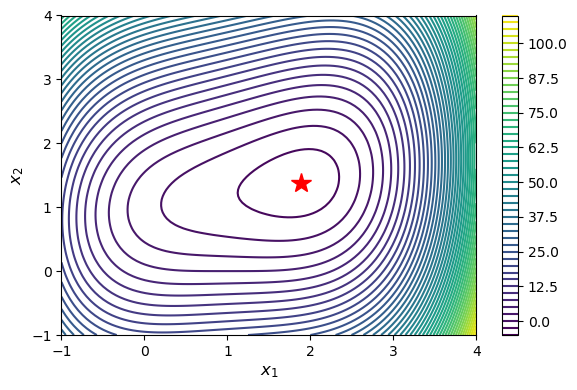

In [173]:
fig, ax = plt.subplots(figsize=(6, 4))
x_ = y_ = np.linspace(-1, 4, 100)
X, Y = np.meshgrid(x_, y_)
c = ax.contour(X, Y, f_lambda(X, Y), 50)
ax.plot(X_opt['x'][0], X_opt['x'][1], 'r*', markersize=15)
ax.set_xlabel(r"$x_1$", fontsize=12)
ax.set_ylabel(r"$x_2$", fontsize=12)
plt.colorbar(c, ax=ax)
fig.tight_layout()

## Functions with many local minima
The methods used so far can find a local minimum starting from a guess point. Often a function has many local minima so that it is difficult to find the global one, if it does exist. For example the function
$$f(x,y) = 4 sin(\pi x) + 6 sin(\pi y) + (x - 1)^2 + (y - 1)^2$$
has many local minima as can be seen from a plot. One approach to address this problem is do a brute force search, that is, evaluating the function over a number of points in a grid. The point with the lowest minimum will be used as a guess point for one of the other minimization algorithms.

### Function definition for the SciPy optimization methods
We define the objective function to take as input a 1-D array of (x,y) pairs and returning a 1-D array of function values of for each pair of (x,y) coordinates. This type of function definition is required by the SciPy optimization methods.

In [73]:
def f(input_pairs):
    x, y = input_pairs
    return (4 * np.sin(np.pi * x) + 6 * np.sin(np.pi * y)) + (x - 1)**2 + (y - 1)**2

The input data for a mesh grid are X and Y 2-D arrays that contain the x and y values for each grid point. The function definition takes as input an array of pairs so in order to evaluate the function at each (x,y) pair if we start with the X and Y matrices we have to
1. flatten the X and Y matrices
2. build the inputs of (x,y) pairs
3. evaluate the function for the array of (x,y) pairs
4. reshape the output of the function to be like the X and Y matrices  

In [71]:
def func_X_Y_to_XY(f, X, Y):
    s = np.shape(X)
    input_pairs = np.vstack([X.ravel(), Y.ravel()])
    return f(input_pairs).reshape(*s)

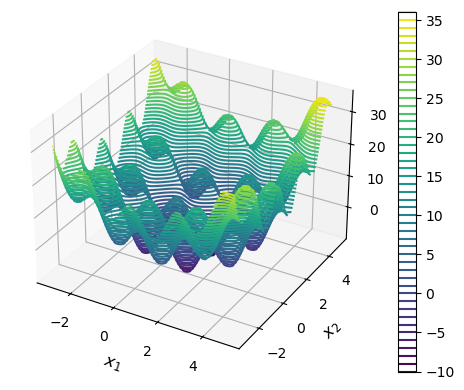

In [49]:
fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': '3d'})
x_ = y_ = np.linspace(-3, 5, 100)
X, Y = np.meshgrid(x_, y_)
Z = func_X_Y_to_XY(f, X, Y)
c = ax.contour(X, Y, Z, 50)
ax.set_xlabel(r"$x_1$", fontsize=12)
ax.set_ylabel(r"$x_2$", fontsize=12)
plt.colorbar(c, ax=ax)
fig.tight_layout()

We define the grid structure where we want to evaluate the objective function, for example a square of length 8 with 16 points on each side. The numer of points in the grid where the objective function will be evaluated is $N^d$ where N is the number of points for each dimension and d is the number of dimensions, so the brute force approach can be computationally expensive for high dimensionality. 

In [5]:
ranges = (slice(-3, 5, 0.5), slice(-3, 5, 0.5))

In [10]:
x_start = optimize.brute(f, ranges, finish=None)
x_start

array([1.5, 1.5])

In [11]:
f(x_start)

-9.5

the x_start point should be a good guess point to look for the global minimum

In [14]:
X_opt = optimize.minimize(f, x_start, method='BFGS')
X_opt

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -9.520229273055016
        x: [ 1.476e+00  1.484e+00]
      nit: 4
      jac: [-7.153e-07 -8.345e-07]
 hess_inv: [[ 2.416e-02  4.605e-06]
            [ 4.605e-06  1.635e-02]]
     nfev: 21
     njev: 7

In [16]:
X_opt['x']

array([1.47586906, 1.48365787])

In [15]:
f(X_opt['x'])

-9.520229273055016

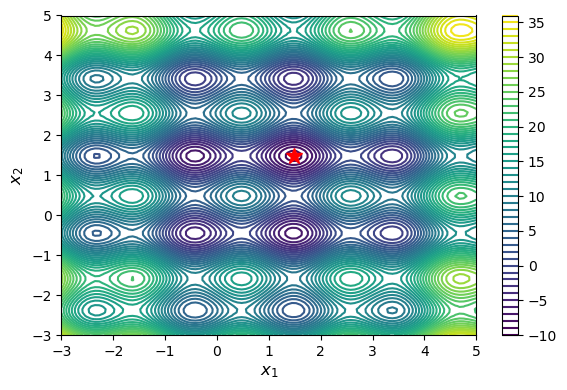

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
x_ = y_ = np.linspace(-3, 5, 100)
X, Y = np.meshgrid(x_, y_)
Z = func_X_Y_to_XY(f, X, Y)
c = ax.contour(X, Y, Z, 50)
ax.plot(X_opt['x'][0], X_opt['x'][1], 'r*', markersize=12)
ax.set_xlabel(r"$x_1$", fontsize=12)
ax.set_ylabel(r"$x_2$", fontsize=12)
plt.colorbar(c, ax=ax)
fig.tight_layout()

## Constrained Optimization
The most obvious kind of constraints are some bounds on the range of the variables used in the objective function. As an example we will find the minimum of the function
$$f(x_1,x_2)=(x_1 - 1)^2 + (x_2 - 1)^2$$
subject to the constraints
$$2 \leq x_1 \leq 3$$
$$0 \leq x_2 \leq 2$$

We plot the function to have a look of its shape. We define our function as matrix operations for visualization purposes.

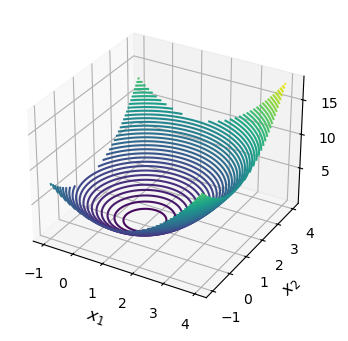

In [15]:
fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': '3d'})
x1 = x2 = np.linspace(-1, 4, 100)
X1, X2 = np.meshgrid(x1, x2)
X3 = (X1 - 1)**2 + (X2 - 1)**2
c = ax.contour(X1, X2, X3, 50)
ax.set_xlabel(r"$x_1$", fontsize=12)
ax.set_ylabel(r"$x_2$", fontsize=12);

in order to use the SciPy optimization algorithm we have to define our function to take as input a 1-D array of (x1,x2) pairs

In [8]:
def f(input_array):
    x1, x2 = input_array
    return (x1 - 1)**2 + (x2 - 1)**2

from the plot we can see that the minimum is at (1,1), that is outside the bounded area

In [9]:
f([1,1])

0

Nevertheless we want to calculate the minimum using the SciPy optimization method starting from a guess point (0,0)

In [10]:
x_opt = optimize.minimize(f, [0, 0], method='BFGS').x
x_opt

array([0.99999999, 0.99999999])

We define the constraints for the two variables x1, x2

In [12]:
bnd_x1, bnd_x2 = (2, 3), (0, 2)

We use another method from the SciPy optimize module that takes into account the constraints

In [13]:
x_cons_opt = optimize.minimize(f, [0, 0], method='L-BFGS-B', bounds=[bnd_x1, bnd_x2]).x
x_cons_opt

array([2., 1.])

We plot the function and the minimum point both inside and outside the constraints. In order to plot the function it must be transform so that the result will have the same shape as the X and Y matrices of the mesh grid

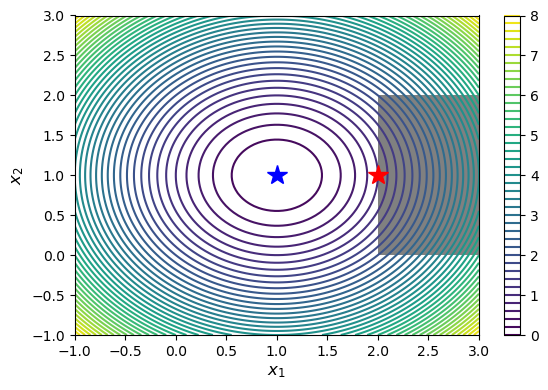

In [79]:
fig, ax = plt.subplots(figsize=(6, 4))
x_ = y_ = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x_, y_)
c = ax.contour(X, Y, func_X_Y_to_XY(f, X, Y), 50)
ax.plot(x_opt[0], x_opt[1], 'b*', markersize=15)
ax.plot(x_cons_opt[0], x_cons_opt[1], 'r*', markersize=15)
bound_rect = plt.Rectangle((bnd_x1[0], bnd_x2[0]), 
                           bnd_x1[1] - bnd_x1[0], bnd_x2[1] - bnd_x2[0],
                           facecolor="grey")
ax.add_patch(bound_rect)
ax.set_xlabel(r"$x_1$", fontsize=12)
ax.set_ylabel(r"$x_2$", fontsize=12)
plt.colorbar(c, ax=ax)

fig.tight_layout()

## References
* [Nocedal, Wright - Numerical Optimization, 2nd Edition](https://www.amazon.com/Numerical-Optimization-Operations-Financial-Engineering-ebook/dp/B014P9ICXI)